# CHILDES Ages 4–6: Child Utterance Statistics

This notebook builds a reproducible sample of CHILDES/CHAT conversations for children aged **4;00 through 5;11** (48 ≤ age in months < 72), then reports statistics on the number of target-child utterances.

It is designed as the data-validation stage for a later **dynamic multi-turn LLM benchmark**.

## Workflow
1. Install/import dependencies.
2. Point the notebook at a CHILDES `.zip`, `.cha` file, or directory of `.cha` files.
3. Load each CHAT transcript separately.
4. Identify the target child from participant metadata (with `CHI` as a fallback).
5. Filter to ages 4–6.
6. Count target-child and total utterances.
7. Display descriptive statistics and plots.
8. Inspect interaction structure.
9. Select balanced, sufficiently long conversations for later multi-turn testing.

> **Age convention:** “4–6” means age ≥ 4 years and < 6 years. Change `MIN_AGE_MONTHS` and `MAX_AGE_MONTHS` if you want a different definition.


In [1]:
# Run once if needed.
%pip install -q pylangacq pandas matplotlib


Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
from zipfile import ZipFile
import tempfile
import re

import pylangacq
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 120)

print("PyLangAcq version:", pylangacq.__version__)


PyLangAcq version: 0.23.0


## 1. Choose the CHILDES data source

`pylangacq.read_chat()` can read a local `.cha` file, a directory containing CHAT files, or a downloaded CHILDES ZIP archive.

Set `DATA_SOURCE` below. Examples:

- `"data/Brown.zip"`
- `"data/CHILDES"`
- `"data/example.cha"`

For a broad ages 4–6 study, use one or more corpora that actually contain children in this age range. Keep corpus/source information when combining datasets so you can check for corpus effects later.


In [3]:
DATA_SOURCE = Path(r"C:\Users\dyl24\CIS4914_SimuLearn\data")   # <-- CHANGE THIS

MIN_AGE_MONTHS = 48
MAX_AGE_MONTHS = 72   # exclusive: 6;00 is not included

MIN_CHILD_UTTERANCES = 100
N_PER_AGE = 10
RANDOM_STATE = 42


## 2. Discover individual CHAT files

We process transcripts one at a time. This makes it straightforward to associate each transcript with its own participant metadata, age, and utterance counts.

If `DATA_SOURCE` is a ZIP archive, this cell extracts it to a temporary working directory for analysis.


In [4]:
_temp_dir = None

def discover_chat_files(source: Path):
    global _temp_dir
    source = Path(source)

    if not source.exists():
        raise FileNotFoundError(
            f"{source} does not exist. Download/copy CHILDES CHAT data "
            "and update DATA_SOURCE."
        )

    if source.is_file() and source.suffix.lower() == ".cha":
        return [source]

    if source.is_dir():
        chat_files = sorted(source.rglob("*.cha"))
        archives = sorted(source.rglob("*.zip"))
        if archives:
            _temp_dir = tempfile.TemporaryDirectory()
            extract_root = Path(_temp_dir.name)
            for index, archive in enumerate(archives):
                archive_dir = extract_root / str(index)
                archive_dir.mkdir()
                with ZipFile(archive, "r") as zf:
                    zf.extractall(archive_dir)
                chat_files.extend(archive_dir.rglob("*.cha"))
        return sorted(chat_files)

    if source.is_file() and source.suffix.lower() == ".zip":
        _temp_dir = tempfile.TemporaryDirectory()
        extract_dir = Path(_temp_dir.name)
        with ZipFile(source, "r") as zf:
            zf.extractall(extract_dir)
        return sorted(extract_dir.rglob("*.cha"))

    raise ValueError("DATA_SOURCE must be a .cha file, .zip archive, or directory.")

cha_files = discover_chat_files(DATA_SOURCE)

print(f"Found {len(cha_files):,} CHAT transcripts.")
cha_files[:5]


Found 1,403 CHAT transcripts.


[WindowsPath('C:/Users/dyl24/AppData/Local/Temp/tmpngh1a715/0/Dinner/andy.cha'),
 WindowsPath('C:/Users/dyl24/AppData/Local/Temp/tmpngh1a715/0/Dinner/bobby.cha'),
 WindowsPath('C:/Users/dyl24/AppData/Local/Temp/tmpngh1a715/0/Dinner/charlie.cha'),
 WindowsPath('C:/Users/dyl24/AppData/Local/Temp/tmpngh1a715/0/Dinner/david.cha'),
 WindowsPath('C:/Users/dyl24/AppData/Local/Temp/tmpngh1a715/0/Dinner/eddie.cha')]

## 3. Helper functions

PyLangAcq represents participant information and ages as structured objects in current releases. These helpers deliberately tolerate small format/version differences.

The target child is selected using the participant role when possible; `CHI` is used as a fallback because it is the standard CHILDES target-child speaker code in many corpora.


In [5]:
def value(obj, name, default=None):
    """Read either an object attribute or dictionary key."""
    if obj is None:
        return default
    if isinstance(obj, dict):
        return obj.get(name, default)
    return getattr(obj, name, default)


def age_in_months(age):
    """Convert a PyLangAcq Age (or compatible value) to months."""
    if age is None:
        return None

    if hasattr(age, "in_months"):
        try:
            return float(age.in_months())
        except Exception:
            pass

    years = value(age, "years")
    months = value(age, "months", 0) or 0
    days = value(age, "days", 0) or 0

    if years is not None:
        return float(years) * 12 + float(months) + float(days) / 30.44

    # Last-resort support for strings such as 4;03.12
    match = re.match(r"^(\d+);(\d+)(?:\.(\d+))?$", str(age))
    if match:
        y, m, d = match.groups()
        return int(y) * 12 + int(m) + (int(d or 0) / 30.44)

    return None


def find_target_child(reader):
    """Return (speaker_code, participant_info) for the target child."""
    participants = reader.participants()

    # Current PyLangAcq commonly returns a list for a one-file reader.
    if isinstance(participants, dict):
        iterable = participants.items()
    else:
        iterable = []
        for p in participants:
            code = value(p, "code") or value(p, "participant")
            iterable.append((code, p))

    for code, info in iterable:
        role = str(value(info, "role", "") or "").lower().replace("_", " ")
        if role in {"target child", "target_child", "child"} or "target" in role and "child" in role:
            return code, info

    # Standard CHILDES fallback.
    for code, info in iterable:
        if code == "CHI":
            return code, info

    return None, None


def get_child_age(reader, child_info):
    """Get target-child age from participant metadata, then fall back to reader.ages()."""
    age = value(child_info, "age")
    months = age_in_months(age)
    if months is not None:
        return months

    try:
        ages = reader.ages()
        for age in ages:
            months = age_in_months(age)
            if months is not None:
                return months
    except Exception:
        pass

    return None


## 4. Load transcripts and count child utterances

Each regular `Utterance` has a `participant` speaker code. We count utterances spoken by the identified target child and also preserve total utterance counts for later interaction analysis.


In [6]:
records = []
errors = []

for filepath in cha_files:
    try:
        reader = pylangacq.read_chat(filepath, strict=False)

        child_code, child_info = find_target_child(reader)
        if child_code is None:
            continue

        age_months = get_child_age(reader, child_info)
        if age_months is None:
            continue

        if not (MIN_AGE_MONTHS <= age_months < MAX_AGE_MONTHS):
            continue

        utterances = [
            u for u in reader.utterances()
            if getattr(u, "participant", None) is not None
        ]
        child_utts = [u for u in utterances if u.participant == child_code]

        # Preserve a useful corpus/child path label.
        rel_path = str(filepath)
        corpus = filepath.parts[-3] if len(filepath.parts) >= 3 else filepath.parent.name

        records.append({
            "file": rel_path,
            "corpus": corpus,
            "child_code": child_code,
            "age_months": age_months,
            "age_years": age_months / 12,
            "age_group": int(age_months // 12),
            "child_utterances": len(child_utts),
            "total_utterances": len(utterances),
            "child_share": len(child_utts) / len(utterances) if utterances else float("nan"),
        })

    except Exception as exc:
        errors.append({"file": str(filepath), "error": repr(exc)})

df = pd.DataFrame(records)

print(f"Eligible age 4–6 transcripts: {len(df):,}")
print(f"Files skipped because of parsing/errors: {len(errors):,}")

if not df.empty:
    display(df.head(10))
else:
    print(
        "No eligible transcripts were found. Check DATA_SOURCE and confirm "
        "that the selected corpus contains target children aged 4–6."
    )


Eligible age 4–6 transcripts: 714
Files skipped because of parsing/errors: 0


,file,corpus,child_code,age_months,age_years,age_group,child_utterances,total_utterances,child_share
0,C:\Users\dyl24\AppData\Local\Temp\tmpngh1a715\0\Dinner\andy.cha,0,CHI,50.000000,4.166667,4,209,441,0.473923
1,C:\Users\dyl24\AppData\Local\Temp\tmpngh1a715\0\Dinner\bobby.cha,0,CHI,50.033333,4.169444,4,419,1254,0.334131
2,C:\Users\dyl24\AppData\Local\Temp\tmpngh1a715\0\Dinner\david.cha,0,CHI,50.033333,4.169444,4,227,701,0.323823
3,C:\Users\dyl24\AppData\Local\Temp\tmpngh1a715\0\Dinner\eddie.cha,0,CHI,52.100000,4.341667,4,214,667,0.320840
4,C:\Users\dyl24\AppData\Local\Temp\tmpngh1a715\0\Dinner\frank.cha,0,CHI,62.233333,5.186111,5,125,519,0.240848
5,C:\Users\dyl24\AppData\Local\Temp\tmpngh1a715\0\Dinner\helen.cha,0,CHI,52.466667,4.372222,4,283,925,0.305946
6,C:\Users\dyl24\AppData\Local\Temp\tmpngh1a715\0\Dinner\john.cha,0,CHI,50.766667,4.230556,4,106,654,0.162080
7,C:\Users\dyl24\AppData\Local\Temp\tmpngh1a715\0\Dinner\theresa.cha,0,CHI,51.000000,4.250000,4,164,440,0.372727
8,C:\Users\dyl24\AppData\Local\Temp\tmpngh1a715\0\Dinner\wanda.cha,0,CHI,48.666667,4.055556,4,243,964,0.252075
9,C:\Users\dyl24\AppData\Local\Temp\tmpngh1a715\0\Dinner\xavia.cha,0,CHI,53.000000,4.416667,4,276,623,0.443018


## 5. Descriptive statistics

The first table summarizes the number of child utterances per transcript. The second breaks the sample into 4-year-olds and 5-year-olds.


In [7]:
if not df.empty:
    overall_stats = pd.DataFrame({
        "Statistic": [
            "Number of transcripts",
            "Total child utterances",
            "Mean child utterances / transcript",
            "Median child utterances / transcript",
            "Minimum child utterances",
            "Maximum child utterances",
            "Standard deviation",
        ],
        "Value": [
            len(df),
            df["child_utterances"].sum(),
            df["child_utterances"].mean(),
            df["child_utterances"].median(),
            df["child_utterances"].min(),
            df["child_utterances"].max(),
            df["child_utterances"].std(),
        ],
    })

    display(overall_stats.round(2))

    age_stats = (
        df.groupby("age_group")
          .agg(
              transcripts=("file", "count"),
              total_child_utterances=("child_utterances", "sum"),
              mean_child_utterances=("child_utterances", "mean"),
              median_child_utterances=("child_utterances", "median"),
              std_child_utterances=("child_utterances", "std"),
              min_child_utterances=("child_utterances", "min"),
              max_child_utterances=("child_utterances", "max"),
          )
          .round(2)
    )

    display(age_stats)


,Statistic,Value
0,Number of transcripts,714.00
1,Total child utterances,67422.00
2,Mean child utterances / transcript,94.43
3,Median child utterances / transcript,76.00
4,Minimum child utterances,2.00
5,Maximum child utterances,474.00
6,Standard deviation,85.79


,transcripts,total_child_utterances,mean_child_utterances,median_child_utterances,std_child_utterances,min_child_utterances,max_child_utterances
age_group,,,,,,,
4,349,36449,104.44,79.0,97.18,2,474
5,365,30973,84.86,74.0,72.10,2,414


## 6. Visualize the utterance-count distribution

A histogram is useful before sampling because CHILDES transcript lengths can be highly uneven. The second chart compares the mean number of target-child utterances for ages 4 and 5.


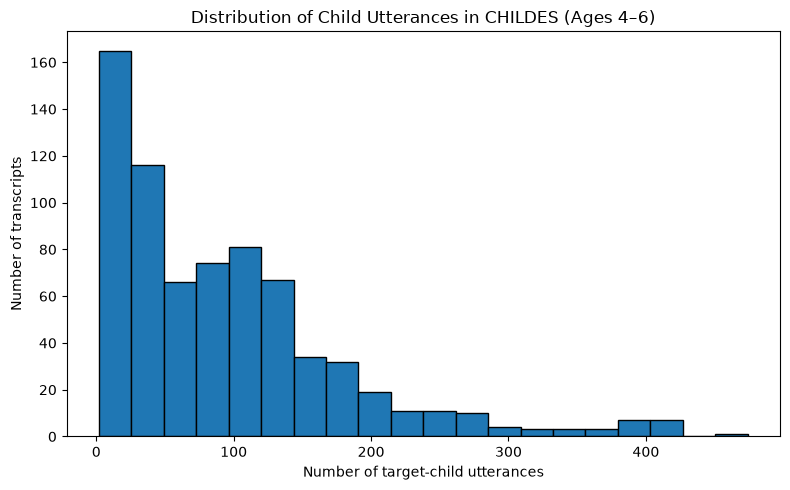

In [8]:
if not df.empty:
    plt.figure(figsize=(8, 5))
    plt.hist(df["child_utterances"], bins=20, edgecolor="black")
    plt.xlabel("Number of target-child utterances")
    plt.ylabel("Number of transcripts")
    plt.title("Distribution of Child Utterances in CHILDES (Ages 4–6)")
    plt.tight_layout()
    plt.show()


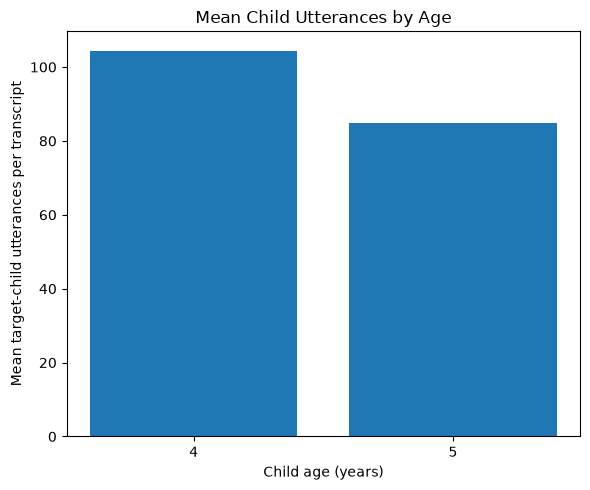

In [9]:
if not df.empty:
    means = df.groupby("age_group")["child_utterances"].mean()

    plt.figure(figsize=(6, 5))
    plt.bar(means.index.astype(str), means.values)
    plt.xlabel("Child age (years)")
    plt.ylabel("Mean target-child utterances per transcript")
    plt.title("Mean Child Utterances by Age")
    plt.tight_layout()
    plt.show()


## 7. Inspect interaction structure

Child-utterance count alone is not enough for a dynamic child–caregiver benchmark. This section also counts:

- target-child turns,
- non-child turns,
- transitions from child → another speaker,
- transitions from another speaker → child,
- consecutive child turns, and
- consecutive non-child turns.

These statistics help identify transcripts that contain sustained interaction rather than mostly isolated speech.


In [10]:
interaction_records = []

eligible_files = set(df["file"]) if not df.empty else set()

for filepath in cha_files:
    if str(filepath) not in eligible_files:
        continue

    reader = pylangacq.read_chat(filepath, strict=False)
    child_code, _ = find_target_child(reader)

    utterances = [
        u for u in reader.utterances()
        if getattr(u, "participant", None) is not None
    ]
    speakers = [u.participant for u in utterances]

    child_to_other = 0
    other_to_child = 0
    consecutive_child = 0
    consecutive_other = 0

    for a, b in zip(speakers, speakers[1:]):
        a_child = a == child_code
        b_child = b == child_code

        if a_child and not b_child:
            child_to_other += 1
        elif not a_child and b_child:
            other_to_child += 1
        elif a_child and b_child:
            consecutive_child += 1
        else:
            consecutive_other += 1

    interaction_records.append({
        "file": str(filepath),
        "non_child_utterances": sum(s != child_code for s in speakers),
        "child_to_other": child_to_other,
        "other_to_child": other_to_child,
        "consecutive_child_turns": consecutive_child,
        "consecutive_non_child_turns": consecutive_other,
        "cross_speaker_transitions": child_to_other + other_to_child,
    })

interaction_df = pd.DataFrame(interaction_records)

if not df.empty:
    df = df.merge(interaction_df, on="file", how="left")
    display(
        df[
            [
                "file",
                "age_years",
                "child_utterances",
                "non_child_utterances",
                "child_to_other",
                "other_to_child",
                "cross_speaker_transitions",
            ]
        ].head(10)
    )


,file,age_years,child_utterances,non_child_utterances,child_to_other,other_to_child,cross_speaker_transitions
0,C:\Users\dyl24\AppData\Local\Temp\tmpngh1a715\0\Dinner\andy.cha,4.166667,209,232,115,114,229
1,C:\Users\dyl24\AppData\Local\Temp\tmpngh1a715\0\Dinner\bobby.cha,4.169444,419,835,238,237,475
2,C:\Users\dyl24\AppData\Local\Temp\tmpngh1a715\0\Dinner\david.cha,4.169444,227,474,165,166,331
3,C:\Users\dyl24\AppData\Local\Temp\tmpngh1a715\0\Dinner\eddie.cha,4.341667,214,453,186,187,373
4,C:\Users\dyl24\AppData\Local\Temp\tmpngh1a715\0\Dinner\frank.cha,5.186111,125,394,113,113,226
5,C:\Users\dyl24\AppData\Local\Temp\tmpngh1a715\0\Dinner\helen.cha,4.372222,283,642,209,210,419
6,C:\Users\dyl24\AppData\Local\Temp\tmpngh1a715\0\Dinner\john.cha,4.230556,106,548,97,97,194
7,C:\Users\dyl24\AppData\Local\Temp\tmpngh1a715\0\Dinner\theresa.cha,4.250000,164,276,138,138,276
8,C:\Users\dyl24\AppData\Local\Temp\tmpngh1a715\0\Dinner\wanda.cha,4.055556,243,721,211,212,423
9,C:\Users\dyl24\AppData\Local\Temp\tmpngh1a715\0\Dinner\xavia.cha,4.416667,276,347,190,190,380


### Important interpretation

Here, “non-child” means **any speaker other than the target child**, not necessarily the primary caregiver. CHILDES transcripts may include mothers, fathers, investigators, siblings, and others.

Before the final multi-turn benchmark, inspect participant roles and define which roles count as caregivers. That avoids incorrectly treating every adult or non-child participant as the caregiver.


## 8. Select conversations suitable for multi-turn testing

Start with a minimum target-child utterance threshold. You can later strengthen this criterion using the number of cross-speaker transitions and verified caregiver roles.


In [11]:
if not df.empty:
    usable_df = df[df["child_utterances"] >= MIN_CHILD_UTTERANCES].copy()

    print(f"Minimum child utterances required: {MIN_CHILD_UTTERANCES}")
    print(f"Usable conversations: {len(usable_df):,}")
    print(f"Available child utterances: {usable_df['child_utterances'].sum():,}")

    display(
        usable_df.sort_values("child_utterances", ascending=False)
                 .head(20)
    )


Minimum child utterances required: 100
Usable conversations: 282
Available child utterances: 49,588


,file,corpus,child_code,age_months,age_years,age_group,child_utterances,total_utterances,child_share,non_child_utterances,child_to_other,other_to_child,consecutive_child_turns,consecutive_non_child_turns,cross_speaker_transitions
122,C:\Users\dyl24\AppData\Local\Temp\tmpngh1a715\1\HV1\MT\tommt1.cha,HV1,CHI,50.100000,4.175000,4,474,976,0.485656,502,343,344,130,158,687
27,C:\Users\dyl24\AppData\Local\Temp\tmpngh1a715\0\Mother\theresa.cha,0,CHI,48.000000,4.000000,4,420,1106,0.379747,686,272,273,147,413,545
1,C:\Users\dyl24\AppData\Local\Temp\tmpngh1a715\0\Dinner\bobby.cha,0,CHI,50.033333,4.169444,4,419,1254,0.334131,835,238,237,181,597,475
24,C:\Users\dyl24\AppData\Local\Temp\tmpngh1a715\0\Mother\frank.cha,0,CHI,62.000000,5.166667,5,414,997,0.415246,583,288,288,126,294,576
15,C:\Users\dyl24\AppData\Local\Temp\tmpngh1a715\0\Father\helen.cha,0,CHI,59.333333,4.944444,4,414,889,0.465692,475,285,286,128,189,571
17,C:\Users\dyl24\AppData\Local\Temp\tmpngh1a715\0\Father\theresa.cha,0,CHI,50.666667,4.222222,4,411,911,0.451153,500,306,306,105,193,612
323,C:\Users\dyl24\AppData\Local\Temp\tmpngh1a715\1\HV2\MT\petmt2.cha,HV2,CHI,55.033333,4.586111,4,406,898,0.452116,492,289,289,117,202,578
609,C:\Users\dyl24\AppData\Local\Temp\tmpngh1a715\1\HV3\MT\rosmt3.cha,HV3,CHI,69.466667,5.788889,5,405,955,0.424084,550,261,261,144,288,522
332,C:\Users\dyl24\AppData\Local\Temp\tmpngh1a715\1\HV2\MT\tommt2.cha,HV2,CHI,59.766667,4.980556,4,399,789,0.505703,390,222,222,177,167,444
19,C:\Users\dyl24\AppData\Local\Temp\tmpngh1a715\0\Father\xavia.cha,0,CHI,51.000000,4.250000,4,395,850,0.464706,455,258,259,136,196,517


## 9. Balanced sampling by age

The source paper used a balanced design across age groups. For this modified ages 4–6 study, the code below attempts to sample the same number of transcripts for age 4 and age 5.

If an age group has fewer than `N_PER_AGE` usable transcripts, the notebook uses all available transcripts in that group rather than failing.


In [12]:
def balanced_sample(frame, n_per_age, random_state=42):
    pieces = []

    for age, group in frame.groupby("age_group"):
        n = min(n_per_age, len(group))
        pieces.append(group.sample(n=n, random_state=random_state))

    if not pieces:
        return frame.iloc[0:0].copy()

    return (
        pd.concat(pieces)
          .sort_values(["age_group", "age_months", "file"])
          .reset_index(drop=True)
    )


if not df.empty:
    sampled_df = balanced_sample(
        usable_df,
        n_per_age=N_PER_AGE,
        random_state=RANDOM_STATE,
    )

    display(
        sampled_df[
            [
                "file",
                "corpus",
                "age_years",
                "child_utterances",
                "total_utterances",
                "cross_speaker_transitions",
            ]
        ]
    )

    print("\nSample summary:")
    display(
        sampled_df.groupby("age_group").agg(
            conversations=("file", "count"),
            child_utterances=("child_utterances", "sum"),
            mean_child_utterances=("child_utterances", "mean"),
            mean_cross_speaker_transitions=("cross_speaker_transitions", "mean"),
        ).round(2)
    )


,file,corpus,age_years,child_utterances,total_utterances,cross_speaker_transitions
0,C:\Users\dyl24\AppData\Local\Temp\tmpngh1a715\0\Father\andy.cha,0,4.050000,222,717,348
1,C:\Users\dyl24\AppData\Local\Temp\tmpngh1a715\1\HV1\MT\davmt1.cha,HV1,4.052778,233,710,348
2,C:\Users\dyl24\AppData\Local\Temp\tmpngh1a715\1\HV1\TP\davtp1.cha,HV1,4.052778,164,425,259
3,C:\Users\dyl24\AppData\Local\Temp\tmpngh1a715\0\Mother\david.cha,0,4.175000,381,1209,537
4,C:\Users\dyl24\AppData\Local\Temp\tmpngh1a715\1\HV2\BR\karbr2.cha,HV2,4.444444,117,479,223
5,C:\Users\dyl24\AppData\Local\Temp\tmpngh1a715\1\HV2\TP\todtp2.cha,HV2,4.677778,115,377,192
6,C:\Users\dyl24\AppData\Local\Temp\tmpngh1a715\1\HV2\TP\kurtp2.cha,HV2,4.791667,122,243,175
7,C:\Users\dyl24\AppData\Local\Temp\tmpngh1a715\1\HV2\BR\tribr2.cha,HV2,4.936111,123,343,212
8,C:\Users\dyl24\AppData\Local\Temp\tmpngh1a715\0\Father\helen.cha,0,4.944444,414,889,571
9,C:\Users\dyl24\AppData\Local\Temp\tmpngh1a715\1\HV2\MT\tommt2.cha,HV2,4.980556,399,789,444



Sample summary:


,conversations,child_utterances,mean_child_utterances,mean_cross_speaker_transitions
age_group,,,,
4,10,2290,229.0,330.9
5,10,1537,153.7,186.1


## 10. Export analysis tables

These CSV files let the next notebook use exactly the same validated sample without repeating the selection step.


In [13]:
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

if not df.empty:
    df.to_csv(OUTPUT_DIR / "childes_age4_6_transcript_statistics.csv", index=False)
    usable_df.to_csv(OUTPUT_DIR / "childes_age4_6_usable_transcripts.csv", index=False)
    sampled_df.to_csv(OUTPUT_DIR / "childes_age4_6_sampled_transcripts.csv", index=False)

    print("Saved:")
    for path in sorted(OUTPUT_DIR.glob("*.csv")):
        print(" -", path)


Saved:
 - output\childes_age4_6_sampled_transcripts.csv
 - output\childes_age4_6_transcript_statistics.csv
 - output\childes_age4_6_usable_transcripts.csv


## Next step: dynamic multi-turn preparation

For the LLM benchmark, the next notebook should:

1. Resolve **caregiver roles** from each selected transcript rather than treating every non-child speaker as a caregiver.
2. Convert the selected CHAT transcripts into ordered child–caregiver turns.
3. Preserve consecutive same-speaker turns (for example, by representing the missing interlocutor response as `<SILENCE>` if reproducing the paper's preprocessing).
4. Save each conversation with age, corpus, transcript ID, speaker role, and utterance text.
5. Use the first reference utterance as the seed for an LLM↔LLM multi-turn conversation.
6. Keep the human CHILDES conversation as the reference distribution for later linguistic and dialogue-level statistics.
